# Necessary imports

In [74]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer



scaler = StandardScaler()


In [75]:
data = pd.read_csv('C:/Users/Morsi Store DZ/rain-prediction/data/train.csv')
print(data.head())

   Day        Date            City  MinTemp  MaxTemp  Rainfall  Evaporation  \
0    0  2010-01-01         Algiers     19.4     31.9       5.0          NaN   
1    1  2010-01-02           Setif     18.6     29.1      12.4          NaN   
2    2  2010-01-03  Sidi Bel Abbes     12.2     29.7       0.0          NaN   
3    3  2010-01-04          Skikda     14.8     32.8       0.0          NaN   
4    4  2010-01-05          Skikda     15.0     35.8       0.0          NaN   

   Sunshine WindGustDir  WindGustSpeed  ... Humidity9am Humidity3pm  \
0       NaN         NNE           39.0  ...        70.0        40.0   
1       NaN           W           56.0  ...        88.0        48.0   
2       NaN           W           30.0  ...        57.0        32.0   
3       NaN          SW           30.0  ...        55.0        24.0   
4       NaN           W           46.0  ...        46.0        13.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1012.2    

In [76]:
print(data.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76672 entries, 0 to 76671
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Day            76672 non-null  int64  
 1   Date           76672 non-null  object 
 2   City           76672 non-null  object 
 3   MinTemp        76453 non-null  float64
 4   MaxTemp        76478 non-null  float64
 5   Rainfall       76672 non-null  float64
 6   Evaporation    46996 non-null  float64
 7   Sunshine       44312 non-null  float64
 8   WindGustDir    71517 non-null  object 
 9   WindGustSpeed  71554 non-null  float64
 10  WindDir9am     70965 non-null  object 
 11  WindDir3pm     75134 non-null  object 
 12  WindSpeed9am   76081 non-null  float64
 13  WindSpeed3pm   75872 non-null  float64
 14  Humidity9am    75811 non-null  float64
 15  Humidity3pm    75834 non-null  float64
 16  Pressure9am    69106 non-null  float64
 17  Pressure3pm    69081 non-null  float64
 18  Cloud9

In [77]:
print(data.describe())

                Day       MinTemp       MaxTemp      Rainfall   Evaporation  \
count  76672.000000  76453.000000  76478.000000  76672.000000  46996.000000   
mean   38335.500000     11.894520     22.833249      2.456764      5.223302   
std    22133.444257      6.361629      6.845794      8.597603      4.025298   
min        0.000000     -8.200000     -4.100000      0.000000      0.000000   
25%    19167.750000      7.400000     17.800000      0.000000      2.575000   
50%    38335.500000     11.700000     22.300000      0.000000      4.400000   
75%    57503.250000     16.500000     27.600000      0.800000      7.000000   
max    76671.000000     31.400000     48.100000    367.600000     82.400000   

           Sunshine  WindGustSpeed  WindSpeed9am  WindSpeed3pm   Humidity9am  \
count  44312.000000   71554.000000  76081.000000  75872.000000  75811.000000   
mean       7.564127      39.776421     13.860806     18.517806     69.327156   
std        3.792560      13.530258      8.878743

In [78]:
missing_values = data.isnull().sum()
print(missing_values)

Day                  0
Date                 0
City                 0
MinTemp            219
MaxTemp            194
Rainfall             0
Evaporation      29676
Sunshine         32360
WindGustDir       5155
WindGustSpeed     5118
WindDir9am        5707
WindDir3pm        1538
WindSpeed9am       591
WindSpeed3pm       800
Humidity9am        861
Humidity3pm        838
Pressure9am       7566
Pressure3pm       7591
Cloud9am         28201
Cloud3pm         28955
Temp9am            469
Temp3pm            471
RainToday            0
RainTomorrow         0
dtype: int64


In [79]:
data.tail()

,Day,Date,City,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
76667,76667,2014-12-27,Annaba,26.1,34.3,0.0,5.0,9.0,NNW,33.0,...,77.0,65.0,1007.0,1004.9,7.0,8.0,28.6,32.2,No,No
76668,76668,2014-12-28,Algiers,26.9,33.6,0.0,5.4,3.9,NW,28.0,...,79.0,56.0,1008.3,1004.9,8.0,7.0,29.1,33.1,No,No
76669,76669,2014-12-29,Sidi Bel Abbes,26.2,33.5,0.0,6.2,3.7,W,28.0,...,77.0,74.0,1008.1,1005.0,7.0,8.0,29.1,30.2,No,Yes
76670,76670,2014-12-30,Skikda,24.8,33.3,3.2,3.6,5.1,N,33.0,...,93.0,54.0,1008.3,1004.8,7.0,7.0,25.5,32.7,Yes,Yes
76671,76671,2014-12-31,Setif,24.7,33.3,13.6,5.4,7.0,N,54.0,...,83.0,60.0,1008.0,1005.1,7.0,7.0,27.8,32.2,Yes,Yes


In [80]:
data['Date'] = pd.to_datetime(data['Date'])

# Convert categorical columns like 'RainToday', 'RainTomorrow' to binary (0/1) or categorical data types
data['RainToday'] = data['RainToday'].map({'Yes': 1, 'No': 0})
data['RainTomorrow'] = data['RainTomorrow'].map({'Yes': 1, 'No': 0})
print(data.info())
data = data.drop_duplicates()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76672 entries, 0 to 76671
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Day            76672 non-null  int64         
 1   Date           76672 non-null  datetime64[ns]
 2   City           76672 non-null  object        
 3   MinTemp        76453 non-null  float64       
 4   MaxTemp        76478 non-null  float64       
 5   Rainfall       76672 non-null  float64       
 6   Evaporation    46996 non-null  float64       
 7   Sunshine       44312 non-null  float64       
 8   WindGustDir    71517 non-null  object        
 9   WindGustSpeed  71554 non-null  float64       
 10  WindDir9am     70965 non-null  object        
 11  WindDir3pm     75134 non-null  object        
 12  WindSpeed9am   76081 non-null  float64       
 13  WindSpeed3pm   75872 non-null  float64       
 14  Humidity9am    75811 non-null  float64       
 15  Humidity3pm    7583

In [81]:
def classify_seasons(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

data['Month'] = data['Date'].dt.month
data['Season'] = data['Month'].apply(classify_seasons)


### Handling Outliers

In [82]:
Q1 = data['Rainfall'].quantile(0.25)
Q3 = data['Rainfall'].quantile(0.75)
#measure spread of 50% middle data 
IQR = Q3 - Q1
#1.5 is a convention from a lot of stat pratctice
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
data = data[(data['Rainfall'] >= lower_bound) & (data['Rainfall'] <= upper_bound)]


In [83]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62522 entries, 2 to 76669
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Day            62522 non-null  int64         
 1   Date           62522 non-null  datetime64[ns]
 2   City           62522 non-null  object        
 3   MinTemp        62346 non-null  float64       
 4   MaxTemp        62356 non-null  float64       
 5   Rainfall       62522 non-null  float64       
 6   Evaporation    38519 non-null  float64       
 7   Sunshine       36092 non-null  float64       
 8   WindGustDir    58485 non-null  object        
 9   WindGustSpeed  58505 non-null  float64       
 10  WindDir9am     57614 non-null  object        
 11  WindDir3pm     61290 non-null  object        
 12  WindSpeed9am   62041 non-null  float64       
 13  WindSpeed3pm   61868 non-null  float64       
 14  Humidity9am    61925 non-null  float64       
 15  Humidity3pm    61912 non

### Normalizing,Scaling Numeric Data

In [84]:
numerical_columns = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'WindSpeed9am', 'WindSpeed3pm']

# Scale numerical columns
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])
data[numerical_columns]


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,WindSpeed9am,WindSpeed3pm
2,0.084638,0.915255,-0.400405,NaN,NaN,-0.503966,-0.853023,-0.592734,-0.485305,-0.509958,0.092915
3,0.488529,1.369549,-0.400405,NaN,NaN,-0.611137,-1.258648,-0.136142,-0.323200,-0.279279,-1.062861
4,0.519598,1.809189,-0.400405,NaN,NaN,-1.093406,-1.816384,-0.519090,-0.632674,-1.086655,-0.138240
5,0.721544,1.516096,-0.400405,NaN,NaN,-0.932650,-2.120603,-0.636920,-0.632674,-1.317333,0.901958
6,0.519598,1.398859,-0.400405,NaN,NaN,-1.146992,-1.613571,-0.519090,-0.455831,-0.509958,NaN
...,...,...,...,...,...,...,...,...,...,...,...
76665,2.274972,1.545405,-0.400405,-0.277632,-0.308603,0.514157,0.515964,-1.505917,-1.723201,-0.048600,-0.831705
76666,2.383711,1.428168,1.634064,0.162081,-0.722012,-0.128868,0.414557,-1.756305,-1.752674,0.989454,0.092915
76667,2.243903,1.589369,-0.400405,-0.131061,0.242608,0.567743,0.820183,-1.682662,-1.605306,0.182079,0.670803
76668,2.368177,1.486786,-0.400405,-0.033347,-1.162981,0.674914,0.363854,-1.491188,-1.605306,-0.279279,0.092915


In [85]:
data.head()

,Day,Date,City,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Month,Season
2,2,2010-01-03,Sidi Bel Abbes,0.084638,0.915255,-0.400405,NaN,NaN,W,30.0,...,-0.592734,-0.485305,NaN,NaN,18.0,28.0,0,0,1,Winter
3,3,2010-01-04,Skikda,0.488529,1.369549,-0.400405,NaN,NaN,SW,30.0,...,-0.136142,-0.323200,NaN,NaN,21.3,30.6,0,0,1,Winter
4,4,2010-01-05,Skikda,0.519598,1.809189,-0.400405,NaN,NaN,W,46.0,...,-0.519090,-0.632674,NaN,NaN,23.3,34.9,0,0,1,Winter
5,5,2010-01-06,Oran,0.721544,1.516096,-0.400405,NaN,NaN,WNW,41.0,...,-0.636920,-0.632674,NaN,NaN,24.3,33.4,0,0,1,Winter
6,6,2010-01-07,Setif,0.519598,1.398859,-0.400405,NaN,NaN,SSE,28.0,...,-0.519090,-0.455831,NaN,1.0,22.8,31.8,0,0,1,Winter


In [86]:
# Perform one-hot encoding on all categorical columns
rain_df_encoded = pd.get_dummies(data, columns=['City', 'WindGustDir', 'RainToday', 'RainTomorrow', 'Season','WindDir9am', 'WindDir3pm'], drop_first=True)
rain_df_encoded

,Day,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
2,2,2010-01-03,0.084638,0.915255,-0.400405,NaN,NaN,30.0,-0.509958,0.092915,...,False,False,False,False,False,False,True,False,False,False
3,3,2010-01-04,0.488529,1.369549,-0.400405,NaN,NaN,30.0,-0.279279,-1.062861,...,True,False,False,False,False,False,False,False,False,False
4,4,2010-01-05,0.519598,1.809189,-0.400405,NaN,NaN,46.0,-1.086655,-0.138240,...,False,True,False,False,False,False,False,False,False,False
5,5,2010-01-06,0.721544,1.516096,-0.400405,NaN,NaN,41.0,-1.317333,0.901958,...,False,False,False,False,False,False,False,True,False,False
6,6,2010-01-07,0.519598,1.398859,-0.400405,NaN,NaN,28.0,-0.509958,NaN,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76665,76665,2014-12-25,2.274972,1.545405,-0.400405,-0.277632,-0.308603,39.0,-0.048600,-0.831705,...,False,False,False,False,False,False,False,True,False,False
76666,76666,2014-12-26,2.383711,1.428168,1.634064,0.162081,-0.722012,39.0,0.989454,0.092915,...,False,False,False,False,False,False,False,True,False,False
76667,76667,2014-12-27,2.243903,1.589369,-0.400405,-0.131061,0.242608,33.0,0.182079,0.670803,...,True,False,False,False,False,False,False,False,False,False
76668,76668,2014-12-28,2.368177,1.486786,-0.400405,-0.033347,-1.162981,28.0,-0.279279,0.092915,...,False,False,False,False,False,False,False,False,True,False


In [87]:
rain_df_encoded.columns

Index(['Day', 'Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
       'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
       'Cloud3pm', 'Temp9am', 'Temp3pm', 'Month', 'City_Annaba', 'City_Batna',
       'City_Bejaia', 'City_Blida', 'City_Constantine', 'City_Oran',
       'City_Setif', 'City_Sidi Bel Abbes', 'City_Skikda', 'WindGustDir_ENE',
       'WindGustDir_ESE', 'WindGustDir_N', 'WindGustDir_NE', 'WindGustDir_NNE',
       'WindGustDir_NNW', 'WindGustDir_NW', 'WindGustDir_S', 'WindGustDir_SE',
       'WindGustDir_SSE', 'WindGustDir_SSW', 'WindGustDir_SW', 'WindGustDir_W',
       'WindGustDir_WNW', 'WindGustDir_WSW', 'RainToday_1', 'RainTomorrow_1',
       'Season_Spring', 'Season_Summer', 'Season_Winter', 'WindDir9am_ENE',
       'WindDir9am_ESE', 'WindDir9am_N', 'WindDir9am_NE', 'WindDir9am_NNE',
       'WindDir9am_NNW', 'WindDir9am_NW', 'WindDir9am_S', 'WindDir9am_SE',
       'Wind

In [88]:
# Check if there are any remaining missing values
print(rain_df_encoded.isnull().sum())


Day                 0
Date                0
MinTemp           176
MaxTemp           166
Rainfall            0
                 ... 
WindDir3pm_SSW      0
WindDir3pm_SW       0
WindDir3pm_W        0
WindDir3pm_WNW      0
WindDir3pm_WSW      0
Length: 78, dtype: int64


In [89]:
# Initialize the KNN Imputer
imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation on the selected numerical columns
rain_df_encoded[numerical_columns] = imputer.fit_transform(rain_df_encoded[numerical_columns])


In [90]:
# Check if there are any remaining missing values
print(rain_df_encoded.isnull().sum())


Day               0
Date              0
MinTemp           0
MaxTemp           0
Rainfall          0
                 ..
WindDir3pm_SSW    0
WindDir3pm_SW     0
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Length: 78, dtype: int64


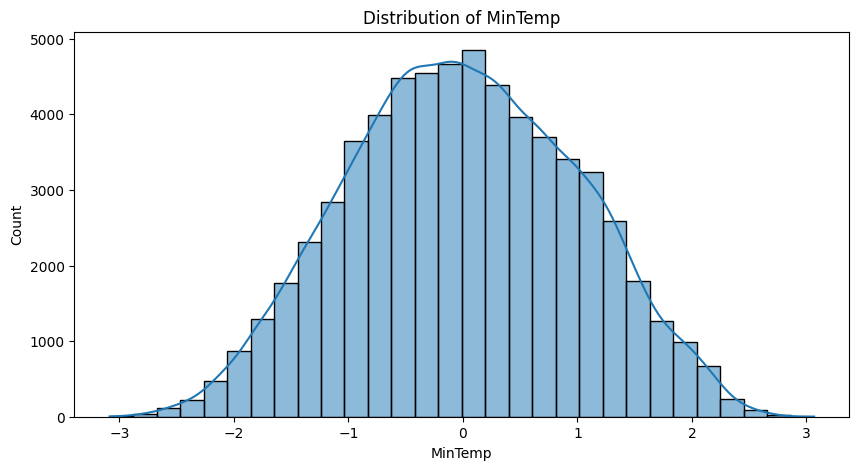

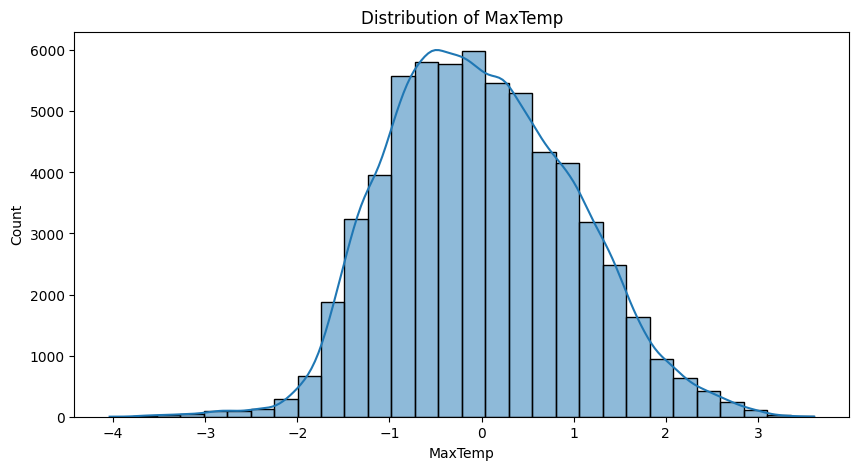

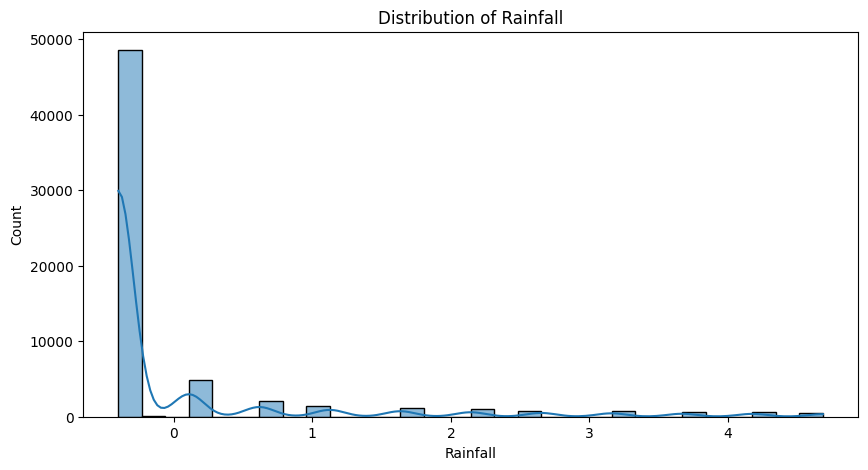

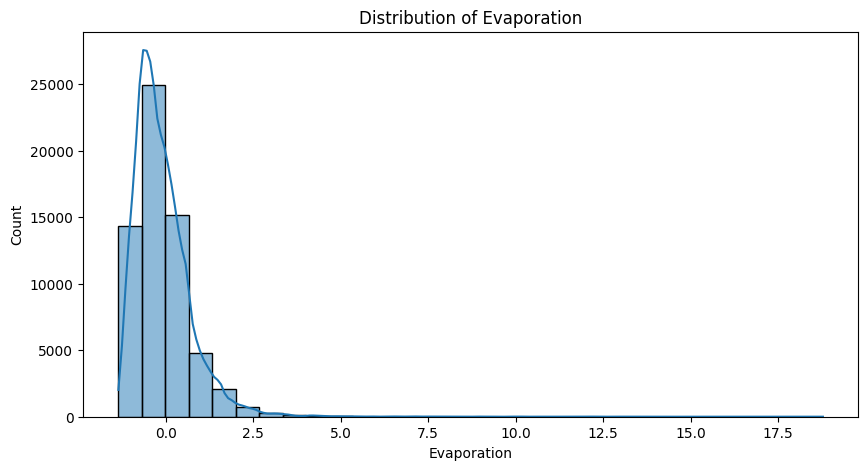

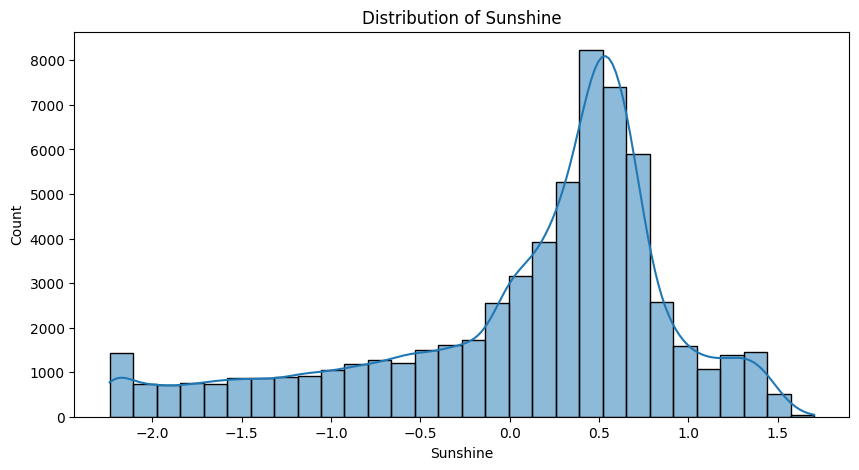

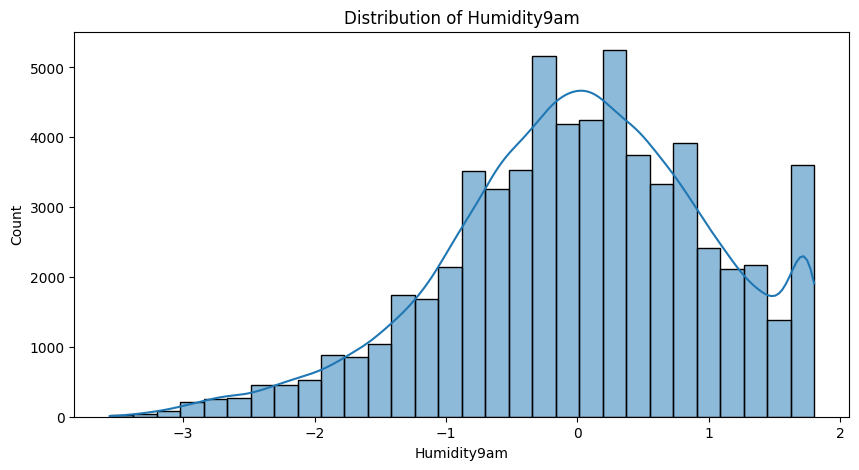

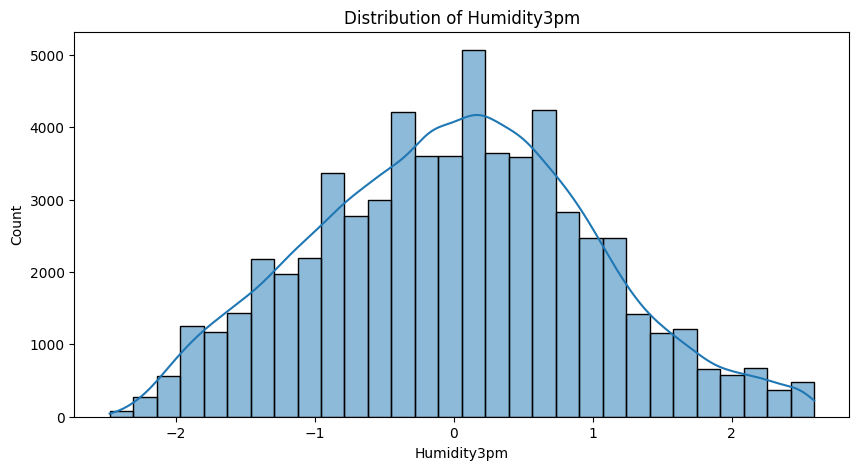

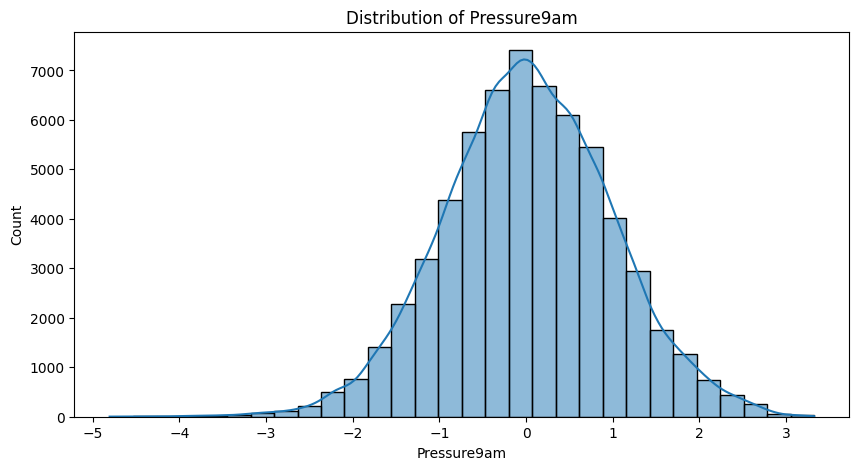

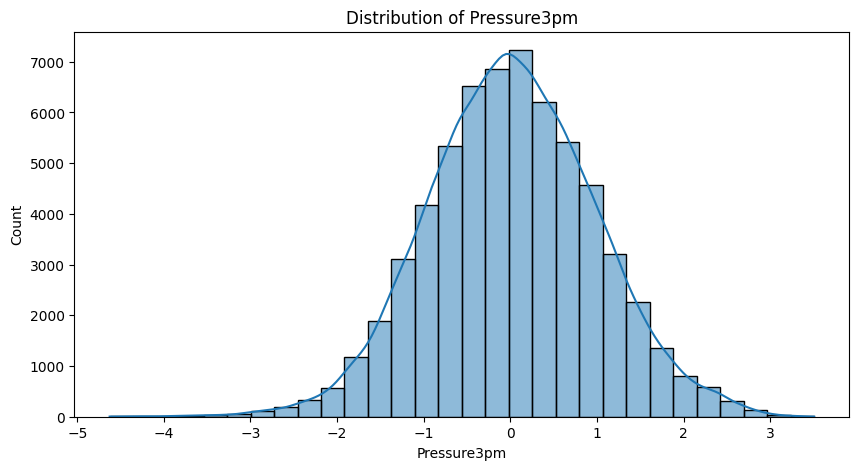

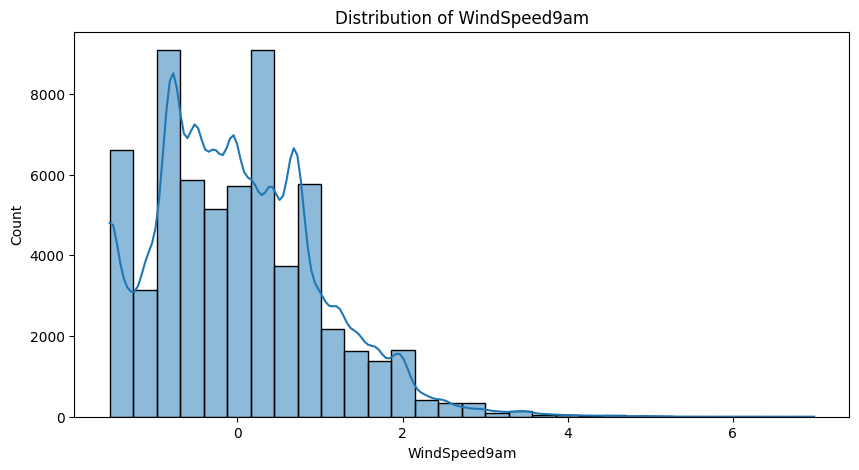

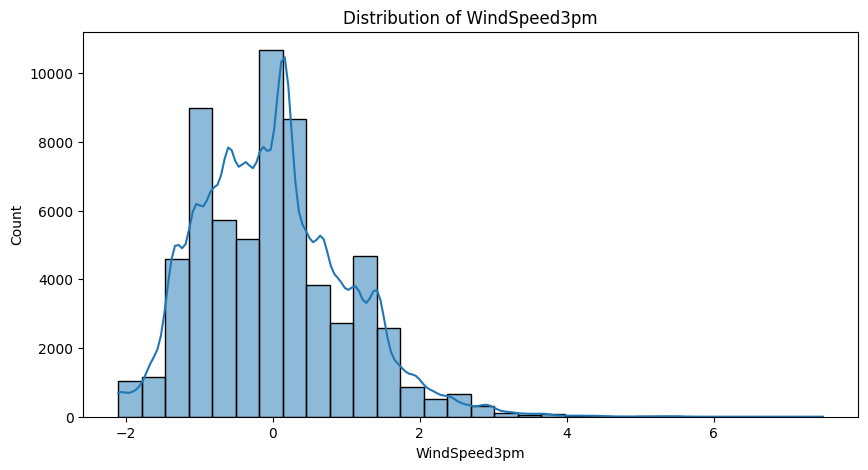

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of the numerical columns
for column in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(rain_df_encoded[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()


In [92]:
print(rain_df_encoded.columns)


Index(['Day', 'Date', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
       'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
       'Cloud3pm', 'Temp9am', 'Temp3pm', 'Month', 'City_Annaba', 'City_Batna',
       'City_Bejaia', 'City_Blida', 'City_Constantine', 'City_Oran',
       'City_Setif', 'City_Sidi Bel Abbes', 'City_Skikda', 'WindGustDir_ENE',
       'WindGustDir_ESE', 'WindGustDir_N', 'WindGustDir_NE', 'WindGustDir_NNE',
       'WindGustDir_NNW', 'WindGustDir_NW', 'WindGustDir_S', 'WindGustDir_SE',
       'WindGustDir_SSE', 'WindGustDir_SSW', 'WindGustDir_SW', 'WindGustDir_W',
       'WindGustDir_WNW', 'WindGustDir_WSW', 'RainToday_1', 'RainTomorrow_1',
       'Season_Spring', 'Season_Summer', 'Season_Winter', 'WindDir9am_ENE',
       'WindDir9am_ESE', 'WindDir9am_N', 'WindDir9am_NE', 'WindDir9am_NNE',
       'WindDir9am_NNW', 'WindDir9am_NW', 'WindDir9am_S', 'WindDir9am_SE',
       'Wind

In [93]:
from sklearn.model_selection import train_test_split

# Define features (drop the target variable 'RainTomorrow_1')
X = rain_df_encoded.drop(['RainTomorrow_1'], axis=1)  # Features
y = rain_df_encoded['RainTomorrow_1']  # Target variable (indicating rain tomorrow)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [94]:
print(X.dtypes)


Day                        int64
Date              datetime64[ns]
MinTemp                  float64
MaxTemp                  float64
Rainfall                 float64
                       ...      
WindDir3pm_SSW              bool
WindDir3pm_SW               bool
WindDir3pm_W                bool
WindDir3pm_WNW              bool
WindDir3pm_WSW              bool
Length: 77, dtype: object


In [95]:
# Convert 'Date' to numeric features
X_train['Year'] = X_train['Date'].dt.year
X_train['Month'] = X_train['Date'].dt.month
X_train['Day'] = X_train['Date'].dt.day
X_train['DayOfWeek'] = X_train['Date'].dt.dayofweek

# Now you can drop the original 'Date' column
X_train = X_train.drop(columns=['Date'])

# Do the same for X_test if you're using a test set
X_test['Year'] = X_test['Date'].dt.year
X_test['Month'] = X_test['Date'].dt.month
X_test['Day'] = X_test['Date'].dt.day
X_test['DayOfWeek'] = X_test['Date'].dt.dayofweek
X_test = X_test.drop(columns=['Date'])


In [96]:
print(X_train.dtypes)


Day                 int32
MinTemp           float64
MaxTemp           float64
Rainfall          float64
Evaporation       float64
                   ...   
WindDir3pm_W         bool
WindDir3pm_WNW       bool
WindDir3pm_WSW       bool
Year                int32
DayOfWeek           int32
Length: 78, dtype: object


In [97]:
# Check for missing values in the dataset
missing_values = X_train.isnull().sum()
print(missing_values[missing_values > 0])


WindGustSpeed     3192
Cloud9am         18553
Cloud3pm         19104
Temp9am            247
Temp3pm            282
dtype: int64


In [98]:
# Drop rows with any missing values
X_train_cleaned = X_train.dropna()
y_train_cleaned = y_train[X_train.index.isin(X_train_cleaned.index)]

# Filling numerical columns with mean
X_train['WindGustSpeed'] = X_train['WindGustSpeed'].fillna(X_train['WindGustSpeed'].mean())
X_train['Temp9am'] = X_train['Temp9am'].fillna(X_train['Temp9am'].mean())
X_train['Temp3pm'] = X_train['Temp3pm'].fillna(X_train['Temp3pm'].mean())

# Filling Cloud columns with the median or mode, depending on your analysis
X_train['Cloud9am'] = X_train['Cloud9am'].fillna(X_train['Cloud9am'].median())
X_train['Cloud3pm'] = X_train['Cloud3pm'].fillna(X_train['Cloud3pm'].median())


In [99]:
from sklearn.impute import SimpleImputer

# Create an imputer for numerical data
imputer = SimpleImputer(strategy='mean')  # or use 'median'

# Fit the imputer on your training data
X_train[['WindGustSpeed', 'Temp9am', 'Temp3pm']] = imputer.fit_transform(X_train[['WindGustSpeed', 'Temp9am', 'Temp3pm']])

# You can create another imputer for Cloud columns if needed
cloud_imputer = SimpleImputer(strategy='median')
X_train[['Cloud9am', 'Cloud3pm']] = cloud_imputer.fit_transform(X_train[['Cloud9am', 'Cloud3pm']])


In [100]:
# Check for remaining missing values
print(X_train.isnull().sum())


Day               0
MinTemp           0
MaxTemp           0
Rainfall          0
Evaporation       0
                 ..
WindDir3pm_W      0
WindDir3pm_WNW    0
WindDir3pm_WSW    0
Year              0
DayOfWeek         0
Length: 78, dtype: int64


In [101]:
# Check the correlation matrix
correlation_matrix = X_train.corr()
print(correlation_matrix)


                     Day   MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  \
Day             1.000000  0.006657  0.014585 -0.004370    -0.003171  0.004582   
MinTemp         0.006657  1.000000  0.738557 -0.007972     0.533875  0.078713   
MaxTemp         0.014585  0.738557  1.000000 -0.203191     0.642048  0.414750   
Rainfall       -0.004370 -0.007972 -0.203191  1.000000    -0.180558 -0.330754   
Evaporation    -0.003171  0.533875  0.642048 -0.180558     1.000000  0.332660   
...                  ...       ...       ...       ...          ...       ...   
WindDir3pm_W   -0.004325 -0.076236 -0.060015  0.032498    -0.023248 -0.017511   
WindDir3pm_WNW -0.001072 -0.055176 -0.026299  0.015567    -0.033176 -0.016772   
WindDir3pm_WSW -0.002671 -0.046644 -0.040656  0.035405     0.006952  0.004261   
Year           -0.007683  0.015908  0.048725 -0.017749     0.065669  0.045565   
DayOfWeek       0.014389  0.008330  0.010981 -0.006778    -0.017676  0.010697   

                WindGustSpe

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=5000)

In [111]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(penalty='l2', C=1.0, max_iter=5000)  # L2 regularization

# Fit the model on the training data
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=5000)

In [112]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [[-1.94467902e-02  8.14853809e-02  5.53448582e-02  1.13229782e-01
   1.17642035e-02 -3.52923082e-01  5.92869908e-01 -1.03583090e-01
  -2.09233455e-01 -5.50357283e-02  1.13236810e+00  7.79042380e-01
  -1.25823987e+00 -6.62420934e-02  3.15162679e-01 -1.41069635e-01
   1.44890506e-01  5.04127846e-02  3.82314083e-03  2.30682216e-02
  -4.62385025e-04  1.40891460e-02  1.08153890e-02 -1.65707064e-03
   3.19790810e-02  1.90696896e-02 -9.70175798e-03 -2.23687652e-02
   2.03966663e-02  4.52918563e-02  1.72919112e-02 -1.44859159e-03
   3.59114820e-02  5.18751277e-02  2.70021592e-02  6.48719592e-02
   6.73627769e-02  3.47571691e-02  5.15103706e-02  5.57539414e-02
   3.94862710e-02  2.84467027e-02 -1.88232290e-02  2.65384687e-02
   3.12473375e-02 -8.35693514e-02  4.82474111e-02 -7.81940467e-03
   4.89758522e-02  6.10854489e-02  1.02765172e-01  2.54994241e-02
   3.25716639e-02 -3.26184390e-02 -1.22652018e-02 -4.90610766e-02
   1.47088814e-02  3.50965351e-02  7.51470051e-03  1.75430368e

In [114]:
from sklearn.impute import SimpleImputer

# Create an imputer object to fill missing values with the column mean
imputer = SimpleImputer(strategy='mean')

# Fit and transform the training data
X_train_imputed = imputer.fit_transform(X_train_scaled)

# Transform the test data (do not fit on the test data)
X_test_imputed = imputer.transform(X_test_scaled)


In [116]:
accuracy = model.score(X_test_imputed, y_test)
print("Model Accuracy:", accuracy)


Model Accuracy: 0.8710115953618552
